In [1]:
!git clone https://github.com/RDS-Rath/EEEM068_Group42.git
%cd EEEM068_Group42

Cloning into 'EEEM068_Group42'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 23 (delta 6), reused 18 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (23/23), 7.70 MiB | 11.96 MiB/s, done.
Resolving deltas: 100% (6/6), done.
/content/EEEM068_Group42


In [2]:
!git checkout Sivaraman_Udaiyappan_01

Branch 'Sivaraman_Udaiyappan_01' set up to track remote branch 'Sivaraman_Udaiyappan_01' from 'origin'.
Switched to a new branch 'Sivaraman_Udaiyappan_01'


In [3]:
!mkdir -p notebooks src data results report

In [4]:
!pwd
!ls

/content/EEEM068_Group42
data  LICENSE  notebooks  README.md  report  results  src


In [5]:
!pip -q install diffusers transformers accelerate safetensors

In [6]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if
      torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [7]:
import os
import torch
from diffusers import StableDiffusionPipeline

os.makedirs("results", exist_ok=True)

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

print("Model loaded successfully")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully


In [8]:
prompts = [
    "anime character with dark hair, portrait, high quality",
    "anime character wearing hoodie with fire design, portrait, high quality",
    "anime character with red hair, portrait, high quality",
    "anime blue ninja character, portrait, high quality",
    "anime character in one leg pose, full body, high quality"
]

titles = [
    "Dark hair",
    "Hoodie + fire",
    "Red hair",
    "Blue ninja",
    "One-leg pose"
]

images = []

for i, prompt in enumerate(prompts):
    image = pipe(prompt).images[0]
    image.save(f"results/img_{i+1}.png")
    images.append(image)

print("5 images generated and saved")

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

5 images generated and saved


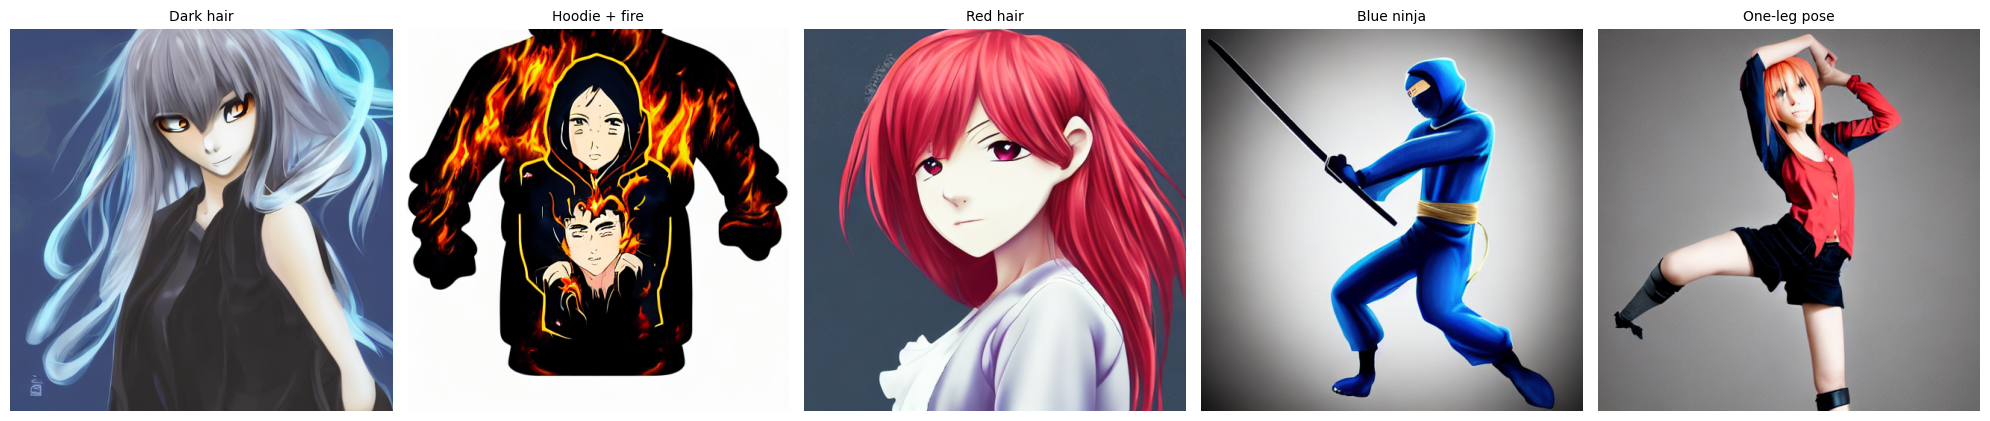

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, ax in enumerate(axes):
    ax.imshow(images[i])
    ax.set_title(titles[i], fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.savefig("results/final_output.png", bbox_inches="tight")
plt.show()

In [10]:
!ls results

final_output.png  img_1.png  img_2.png	img_3.png  img_4.png  img_5.png


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive/Colab Notebooks"